<a href="https://colab.research.google.com/github/majdsindi/dGlDuzvigeybwhVU/blob/main/happiness_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
# data reading
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Apziva/ACME-HappinessSurvey2020.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


In [ ]:
df.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


# EDA

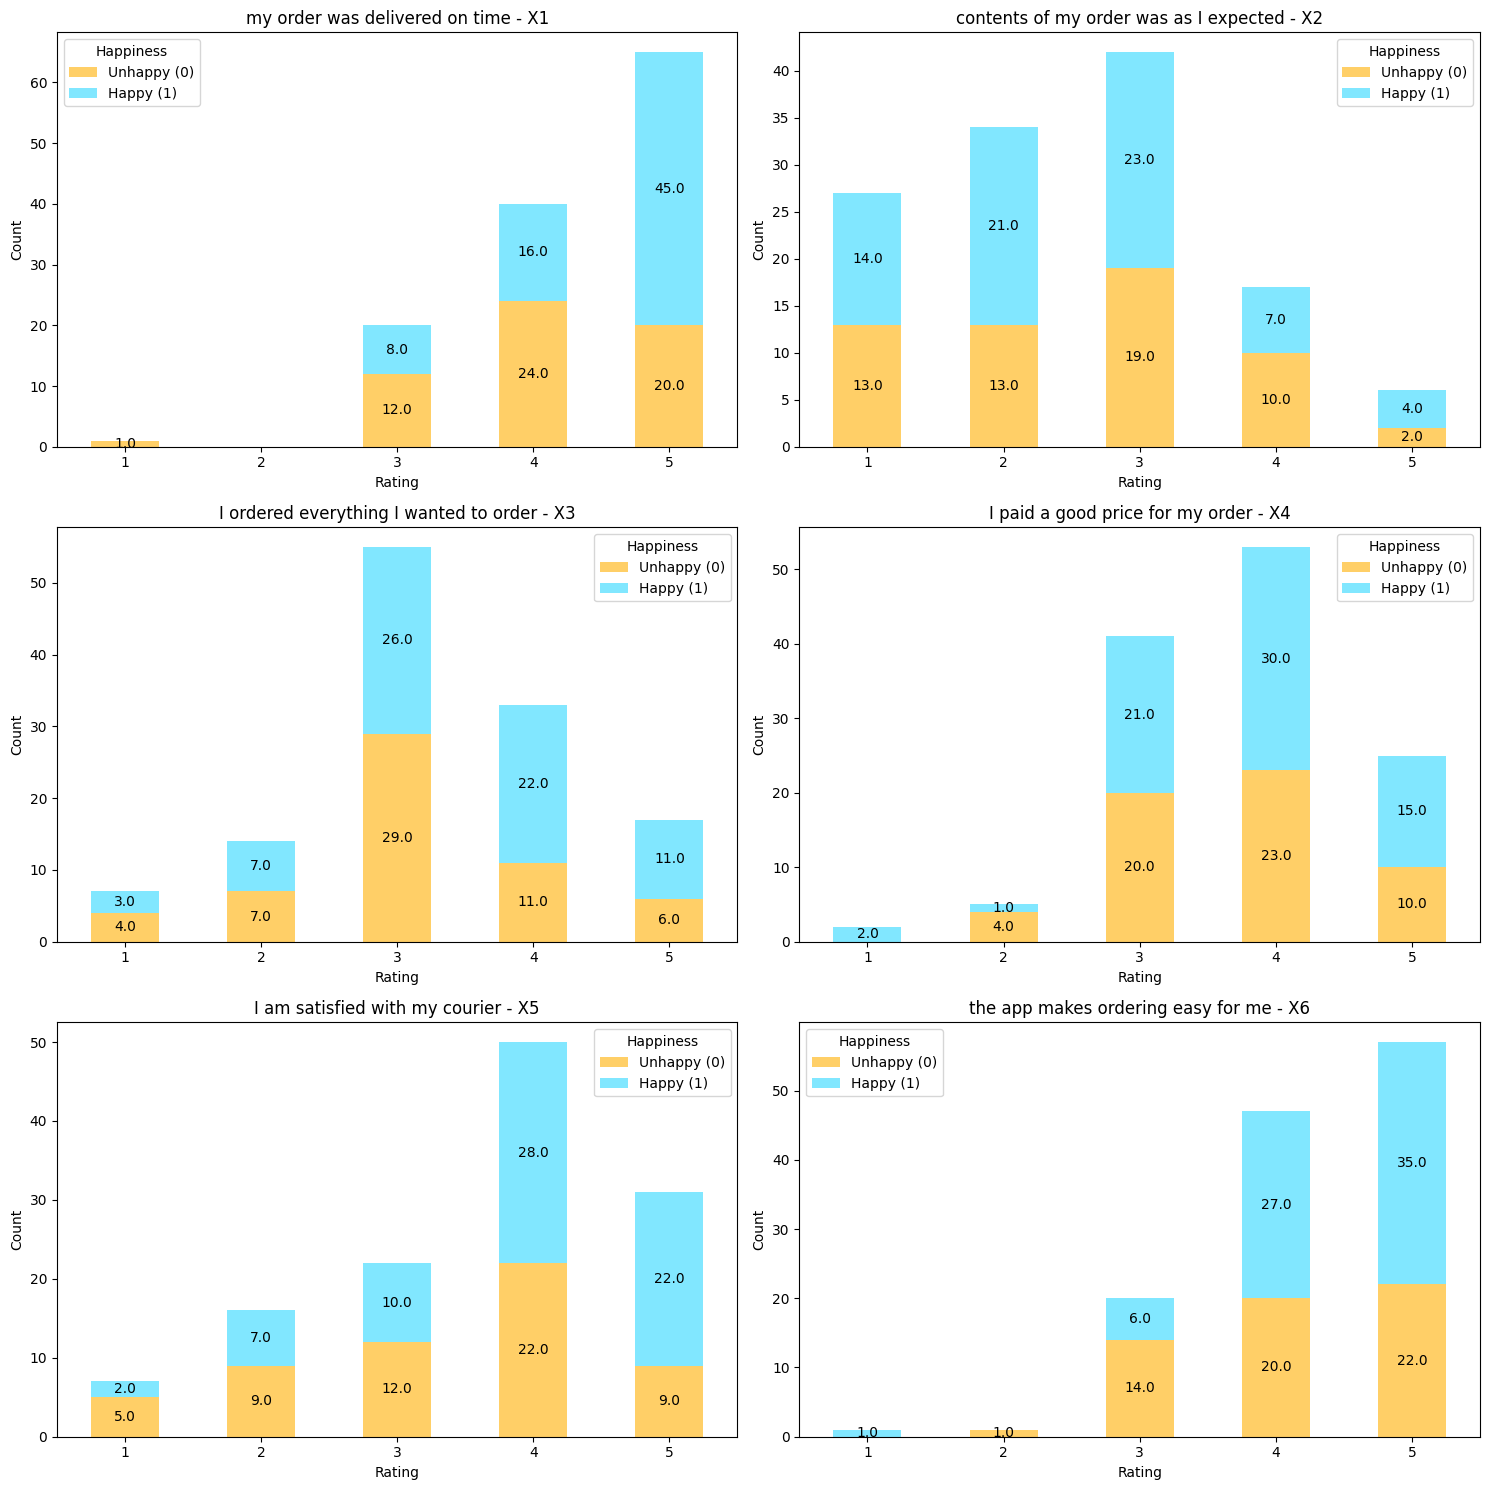

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
questions = {'X1':'my order was delivered on time',
             'X2':'contents of my order was as I expected',
             'X3':'I ordered everything I wanted to order',
             'X4':'I paid a good price for my order',
             'X5':'I am satisfied with my courier',
             'X6':'the app makes ordering easy for me'
             }

for i, col in enumerate(columns):
    # group by the current X column and Y, then count occurrences then unstack Y
    # to get counts for Y=0 and Y=1 side-by-side
    plot_data = df.groupby([col, 'Y']).size().unstack(fill_value=0)

    # Ensure all ratings from 1 to 5 are present in the index
    full_index = pd.Index(range(1, 6), name=col)
    plot_data = plot_data.reindex(full_index, fill_value=0)

    #plot a stacked bar chart for the current X column
    ax = plot_data.plot(kind='bar', stacked=True, ax=axes[i], cmap='managua')

    for c in ax.containers:
      # Optional: if the segment is small or 0, customize the labels
      labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
      # remove the labels parameter if it's not needed for customized labels
      ax.bar_label(c, labels=labels, label_type='center')

    # set title and labels
    axes[i].set_title(f'{questions[col]} - {col}', fontsize=12)
    axes[i].set_xlabel('Rating', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=0) # Keep x-axis labels horizontal
    axes[i].legend(title='Happiness', labels=['Unhappy (0)', 'Happy (1)'])

plt.tight_layout()
plt.show()

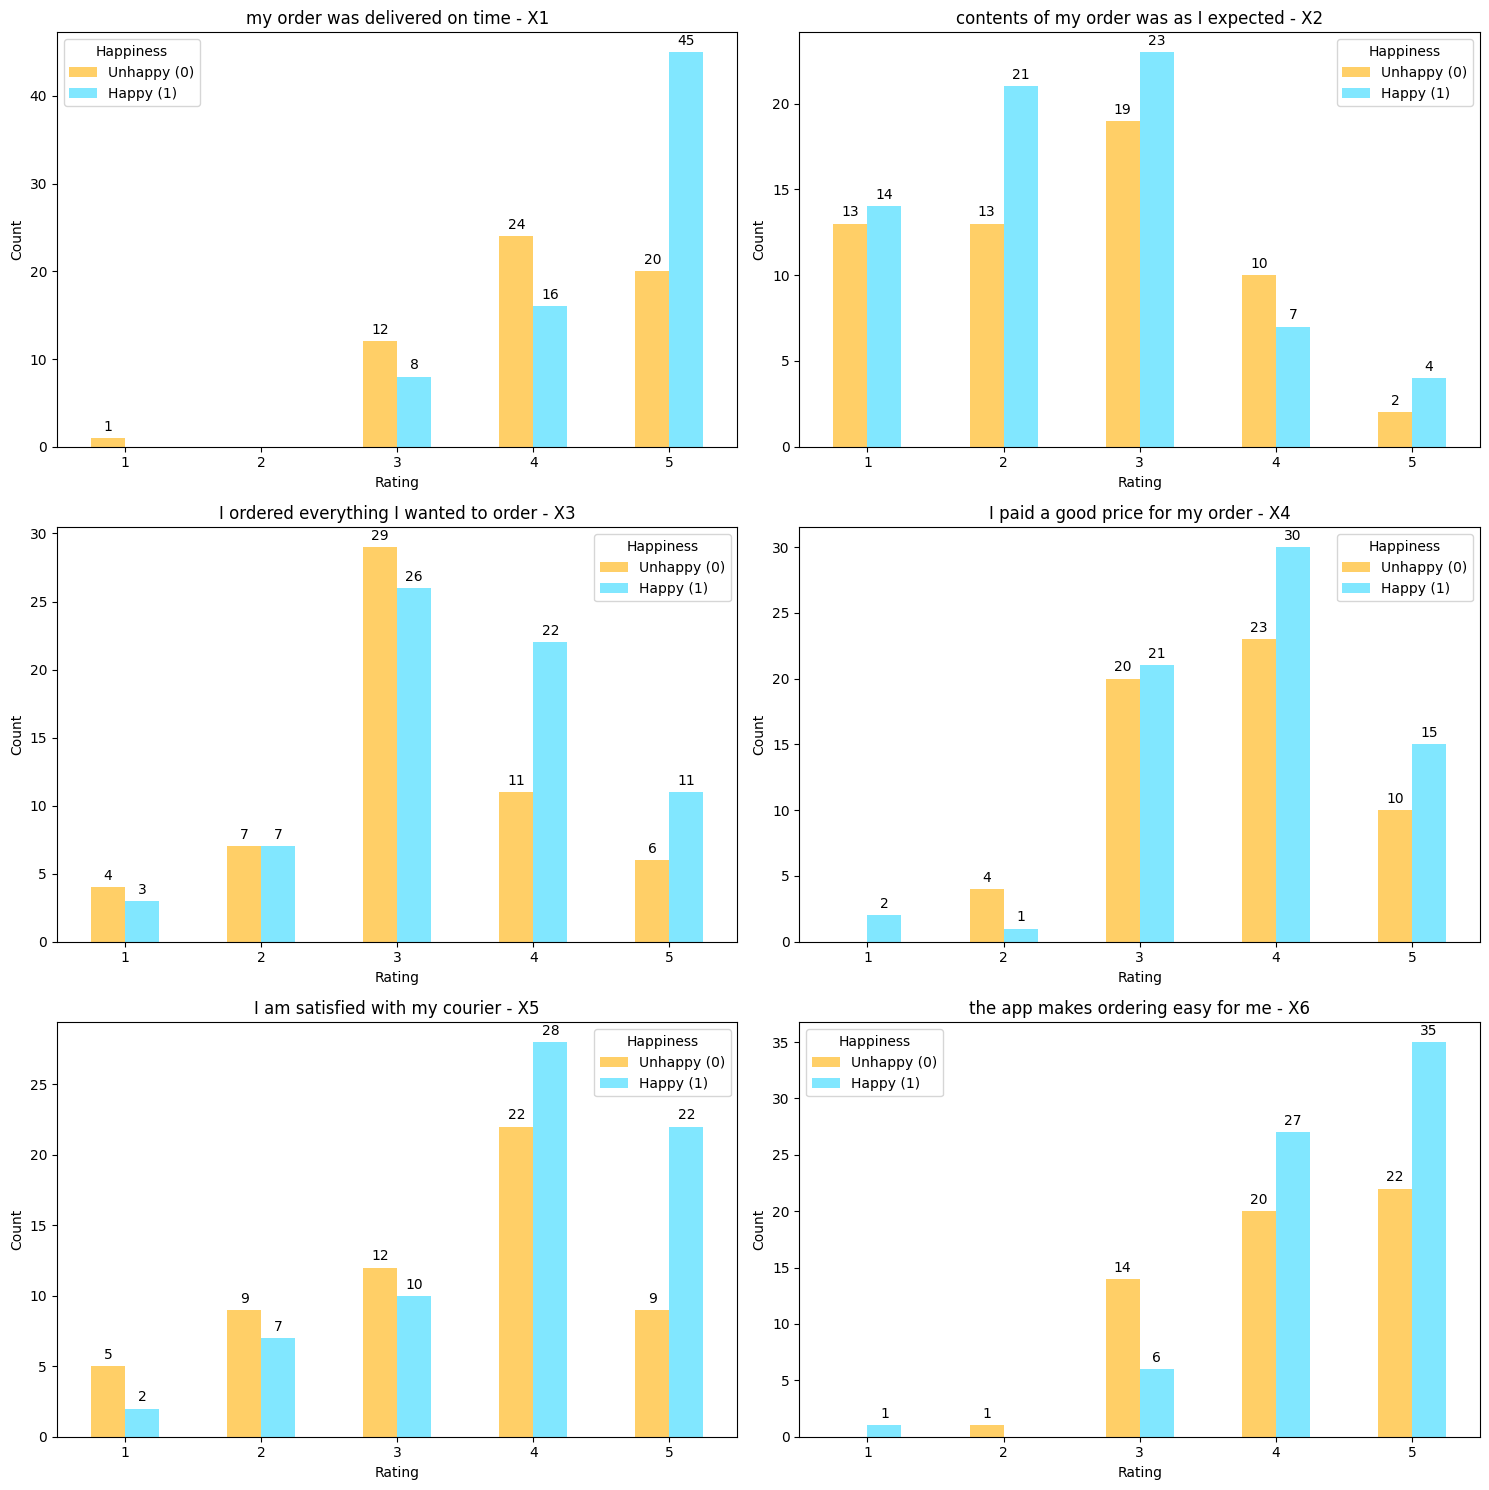

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
questions = {'X1':'my order was delivered on time',
             'X2':'contents of my order was as I expected',
             'X3':'I ordered everything I wanted to order',
             'X4':'I paid a good price for my order',
             'X5':'I am satisfied with my courier',
             'X6':'the app makes ordering easy for me'
             }

for i, col in enumerate(columns):
    # group by the current X column and Y, then count occurrences then unstack Y
    # to get counts for Y=0 and Y=1 side-by-side
    plot_data = df.groupby([col, 'Y']).size().unstack(fill_value=0)

    # Ensure all ratings from 1 to 5 are present in the index
    full_index = pd.Index(range(1, 6), name=col)
    plot_data = plot_data.reindex(full_index, fill_value=0)

    # Plot side-by-side bar chart for the current X column
    ax = plot_data.plot(kind='bar', stacked=False, ax=axes[i], cmap='managua')

    for c in ax.containers:
      # Optional: if the segment is small or 0, customize the labels
      labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
      # Adjust label positioning for side-by-side bars
      ax.bar_label(c, labels=labels, label_type='edge', padding=3)

    # set title and labels
    axes[i].set_title(f'{questions[col]} - {col}', fontsize=12)
    axes[i].set_xlabel('Rating', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=0) # Keep x-axis labels horizontal
    axes[i].legend(title='Happiness', labels=['Unhappy (0)', 'Happy (1)'])

plt.tight_layout()
plt.show()

###Discussion
X1 (order delivered on time) shows the general trend of good service and happy customers. the histogram is skewed to the right and the higher the score the happier the customers. however the number of unhappy customers voting high is indicative of a problem elsewhere.

X2 (contents of order were as I expected) has a centered normal distribution with a slight skew towards 0 and a failry 50/50 split of happy to unhappy customers. This tells us that people are not too bothered by having substitutions/different contents of an order but substitutions are slightly contributing to bad service, even though people don't mind it.

X3 (I ordered everything I wanted) is normally distributed with a slight skew to the right. Here the percentage of happy customers rises the higher the rating. This means this is probably a feature that will influence the model. however this affects happy customers and not unhappy customers.

X4 (I paid a good price) is heavliy skewed to the right. and the percentage of happy customers increases with the rating though not significantly.

X5 (happy with my courier) is the most influential feature. the lower the courier rating the more unhappy customers there are. this is likely where the main problem exists.

X6 (The app makes ordering easy) is helpful but not as much as X5 due to there being not much ratings at 1 and 2.

### Pearson Correlation Matrix

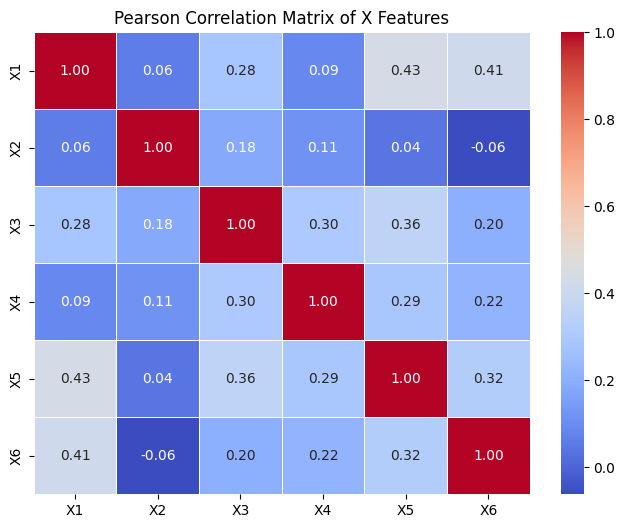

In [ ]:
X_data = df.loc[:, 'X1':'X6']
correlation_matrix = X_data.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Pearson Correlation Matrix of X Features')
plt.show()

## Correlation matrix based on happiness

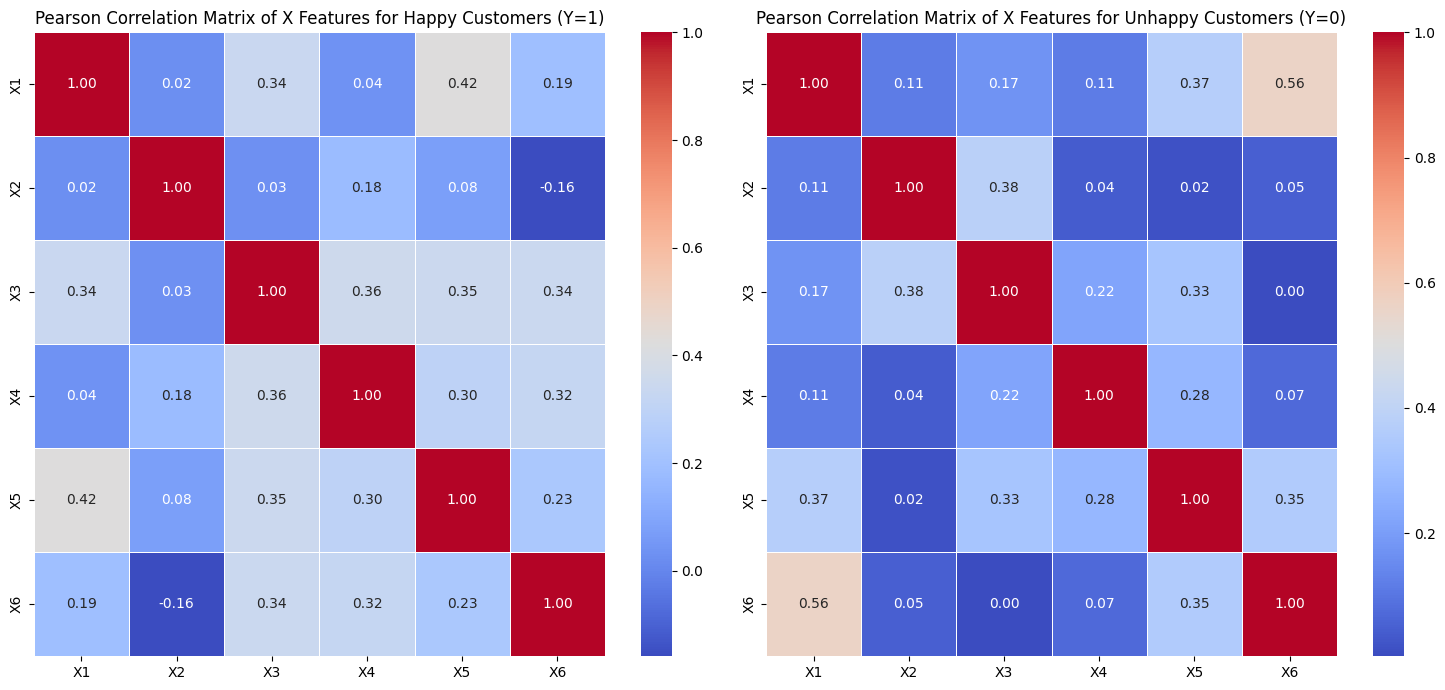

In [ ]:
happy_customers_df = df[df['Y'] == 1]
X_data_happy = happy_customers_df.loc[:, 'X1':'X6']
correlation_matrix_happy = X_data_happy.corr(method='pearson')

unhappy_customers_df = df[df['Y'] == 0]
X_data_unhappy = unhappy_customers_df.loc[:, 'X1':'X6']
correlation_matrix_unhappy = X_data_unhappy.corr(method='pearson')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))

sns.heatmap(correlation_matrix_happy, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax[0])
ax[0].set_title('Pearson Correlation Matrix of X Features for Happy Customers (Y=1)')

sns.heatmap(correlation_matrix_unhappy, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, ax=ax[1])
ax[1].set_title('Pearson Correlation Matrix of X Features for Unhappy Customers (Y=0)')
plt.tight_layout()
plt.show()

#Train some classifiers using lazy predict


In [ ]:
pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.9 MB/s eta 0:00:00


In [ ]:
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

import random

Uncomment the below cell to perform the search for the best seed (runtime ~4 hours)

In [ ]:
# # do a for loop to find the best seed

# # Separate features (X) and target (Y)
# X = df.drop('Y', axis=1)
# Y = df['Y']

# score_list = []

# for seed in range(1000, 10000):
#   X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=seed, stratify=Y)
#   clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
#   models, predictions = clf.fit(X_train, X_test, y_train, y_test)

#   # Ensure models is sorted before taking iloc[0] to get the highest scoring model
#   models_sorted = models.sort_values(by='Balanced Accuracy', ascending=False)

#   # find the balanced accuracy of the highest scoring model
#   model_score_avg = np.mean(models_sorted.iloc[0:4]['Balanced Accuracy'])
#   print(f"Average top 4 model score for seed {seed} is: {model_score_avg}")

#   score_list.append({'seed number': seed, 'average score': model_score_avg})

# # Convert the list of results to a DataFrame
# sorted_seed_search_results_avg = pd.DataFrame(score_list)

# # Sort the DataFrame by 'highest score'
# sorted_seed_search_results_avg = sorted_seed_search_results_avg.sort_values(by='average score', ascending=False).reset_index(drop=True)

# print("Sorted results by top 4 average score:")
# print(sorted_seed_search_results_avg)

# # save the sorted results to a csv file
# sorted_seed_search_results_avg.to_csv('/content/drive/MyDrive/Colab_Notebooks/Apziva/sorted_seed_search_results_avg.csv', index=False)

In [ ]:
# Display report for the best seed
# Separate features (X) and target (Y)
X = df.drop('Y', axis=1)
Y = df['Y']

seed = 6527

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=seed, stratify=Y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


# Use lazy classifier to see which models perform best
# Initialize lazy classifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit LazyClassifier to the training data
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

print(models)

X_train shape: (100, 6)
X_test shape: (26, 6)
y_train shape: (100,)
y_test shape: (26,)
                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
NearestCentroid                0.923077           0.916667  0.922619   
BernoulliNB                    0.884615           0.875000  0.916667   
AdaBoostClassifier             0.846154           0.833333  0.812500   
LinearSVC                      0.846154           0.833333  0.869048   
LogisticRegression             0.846154           0.833333  0.869048   
LinearDiscriminantAnalysis     0.846154           0.833333  0.869048   
RidgeClassifier                0.846154           0.833333  0.869048   
GaussianNB                     0.846154           0.833333  0.910714   
RidgeClassifierCV              0.807692           0.791667  0.869048   
LGBMClassifier                 0.769231           0.761905  0.696429   
Perceptron                     0.692308         

# Choose AdaboostClassifier, SGDClassifier, NearestCentroid, BernoulliNB, and LogisticRegression

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import NearestCentroid
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import ConfusionMatrixDisplay

## Nearest Centroid Classifier

In [ ]:
# Initialize and train the NearestCentroid classifier
nearest_centroid_clf = NearestCentroid()
nearest_centroid_clf.fit(X_train, y_train)


print(nearest_centroid_clf.get_params(deep=True))

# Make predictions on the test set
y_pred_nearest_centroid = nearest_centroid_clf.predict(X_test)

# # Plot the confusion matrix
# fig, ax = plt.subplots(figsize=(6, 6))
# ConfusionMatrixDisplay.from_estimator(nearest_centroid_clf, X_test, y_test, cmap='Blues', ax=ax)
# ax.set_title('NearestCentroid Confusion Matrix')
# plt.show()

{'metric': 'euclidean', 'priors': 'uniform', 'shrink_threshold': None}


## Bernoulli Naive Bayes Classifier

In [ ]:
# Initialize and train the BernoulliNB classifier
bernoulli_nb_clf = BernoulliNB()
bernoulli_nb_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_bernoulli_nb = bernoulli_nb_clf.predict(X_test)

# # Plot the confusion matrix
# fig, ax = plt.subplots(figsize=(6, 6))
# ConfusionMatrixDisplay.from_estimator(bernoulli_nb_clf, X_test, y_test, cmap='Blues', ax=ax)
# ax.set_title('BernoulliNB Confusion Matrix')
# plt.show()

## AdaBoostClassifier

In [ ]:
# Initialize and train the AdaBoostClassifier
adaboost_clf = AdaBoostClassifier(random_state=seed)
adaboost_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_adaboost = adaboost_clf.predict(X_test)

# # Plot the confusion matrix
# fig, ax = plt.subplots(figsize=(6, 6))
# ConfusionMatrixDisplay.from_estimator(adaboost_clf, X_test, y_test, cmap='Blues', ax=ax)
# ax.set_title('AdaBoostClassifier Confusion Matrix')
# plt.show()

## Linear SVC

In [ ]:
# Initialize and train the LinearSV Classifier
linearsvc_clf = LinearSVC(random_state=seed)
linearsvc_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linearsvc = linearsvc_clf.predict(X_test)

# # Plot the confusion matrix
# fig, ax = plt.subplots(figsize=(6, 6))
# ConfusionMatrixDisplay.from_estimator(linearsvc_clf, X_test, y_test, cmap='Blues', ax=ax)
# ax.set_title('LinearSVC Confusion Matrix')
# plt.show()

## Logistic Regression

In [ ]:
# Initialize and train the LinearSV Classifier
logistic_clf = LogisticRegression(random_state=seed)
logistic_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_logistic = logistic_clf.predict(X_test)

# # Plot the confusion matrix
# fig, ax = plt.subplots(figsize=(6, 6))
# ConfusionMatrixDisplay.from_estimator(logistic_clf, X_test, y_test, cmap='Blues', ax=ax)
# ax.set_title('Logistic Regression Confusion Matrix')
# plt.show()

#Confusion matrices in one plot

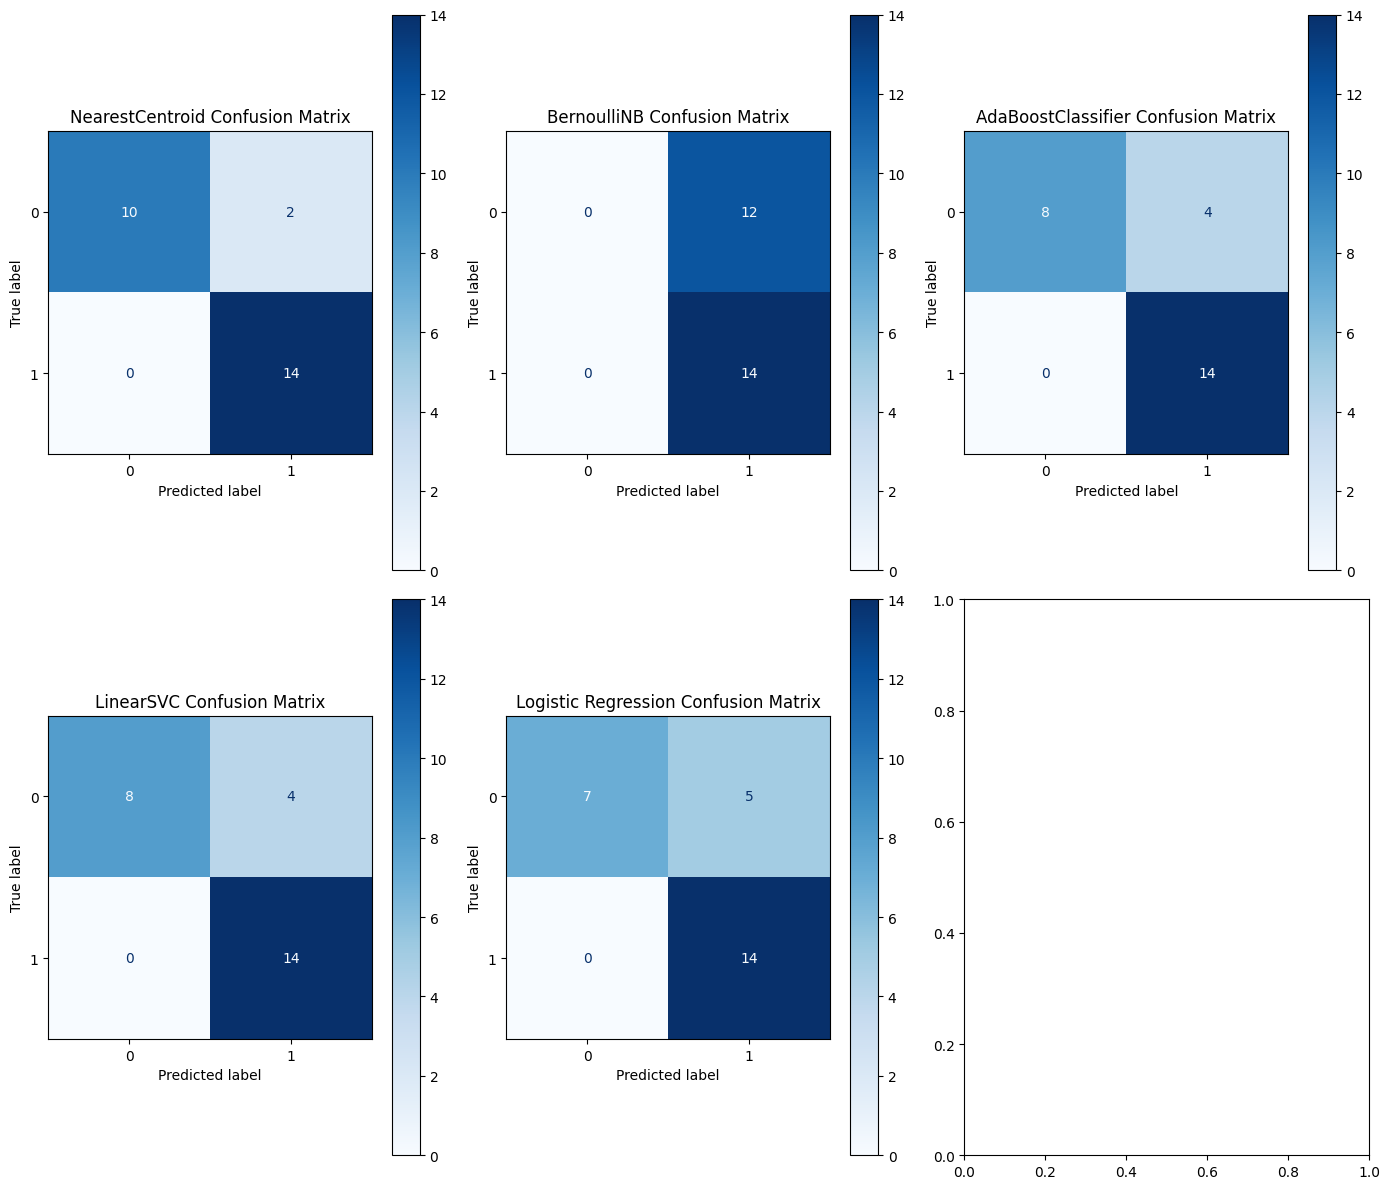

In [ ]:
classifiers = {
    "NearestCentroid": nearest_centroid_clf,
    "BernoulliNB": bernoulli_nb_clf,
    "AdaBoostClassifier": adaboost_clf,
    "LinearSVC": linearsvc_clf,
    "Logistic Regression": logistic_clf
    }

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 12))
axes = axes.flatten()

for i, (name, clf) in enumerate(classifiers.items()):
    ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

BernoulliNB is struggling to perform with this dataset so it will be ommitted from further testing

# Test voting classifier and stacking ensambling

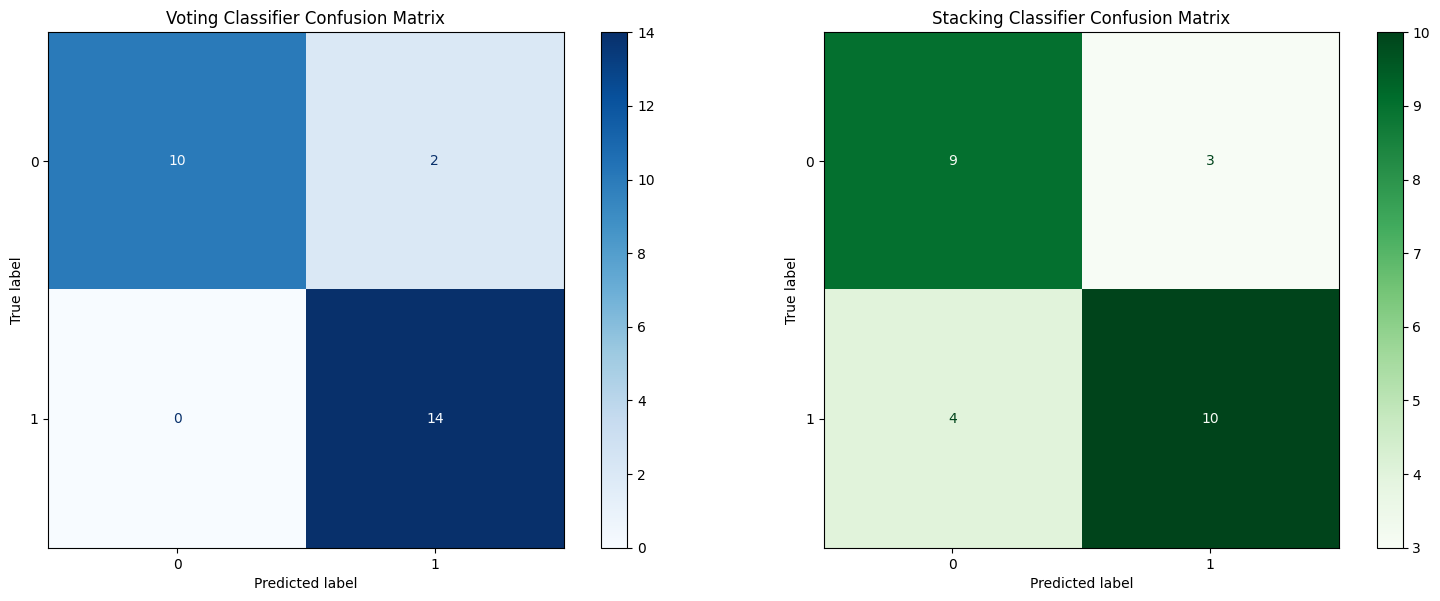

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Define the base estimators for Voting and Stacking Classifiers
# Use unfitted estimators so the ensemble can train them
estimators = [
    ('nearest_centroid', NearestCentroid()),
    # ('bernoulli_nb', BernoulliNB()),
    ('adaboost', AdaBoostClassifier(random_state=seed)),
    ('linear_svc', LinearSVC(random_state=seed, dual=False)) # Added dual=False for LinearSVC as per sklearn documentation to avoid warning with large number of samples
]

# Initialize and train the VotingClassifier
voting_clf = VotingClassifier(
    estimators=estimators,
    voting='hard'
    ) # I would like soft, but it doesn't work with LinSVC and NC
voting_clf.fit(X_train, y_train)

# Make predictions with the VotingClassifier
y_pred_voting = voting_clf.predict(X_test)



# Initialize and train the StackingClassifier
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=seed, class_weight='balanced'), #because classes are not balanced
    passthrough=True # Added passthrough=True to feed original features to the final_estimator
    )
# why using LogisticRegression as the final estimator??
stacking_clf.fit(X_train, y_train)

# Make predictions with the Stacking Classifier
y_pred_stacking = stacking_clf.predict(X_test)



# Plot Confusion Matrices for both ensemble classifiers
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

ConfusionMatrixDisplay.from_estimator(voting_clf, X_test, y_test, cmap='Blues', ax=axes[0])
axes[0].set_title('Voting Classifier Confusion Matrix')

ConfusionMatrixDisplay.from_estimator(stacking_clf, X_test, y_test, cmap='Greens', ax=axes[1])
axes[1].set_title('Stacking Classifier Confusion Matrix')

plt.tight_layout()
plt.show()

Ensambling doesn't seem to add any value as the results are mirroring what NCC results looked like

# RFE doesn't work with NCC so we do it manually. Then I will try Univariate Feature Selection using SelectKBest

In [ ]:
# re-establish test-train split
X = df.drop('Y', axis=1)
Y = df['Y']

seed = 6527

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=seed, stratify=Y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (100, 6)
X_test shape: (26, 6)
y_train shape: (100,)
y_test shape: (26,)


In [ ]:
import itertools
from sklearn.metrics import balanced_accuracy_score

def manual_RFE_with_NCC(X_train, X_test, y_train, y_test, n_features_to_drop):
  """
    Evaluates Nearest Centroid Classifier on the selected data recursively
    omitting the specified number of features for each possible combination
  """
  results = []

  # iterate over every combination of dropped features
  for dropped_features in itertools.combinations(columns, n_features_to_drop):

    # Create copies of training and testing data with selected features dropped
    X_train_copy = X_train.copy().drop(list(dropped_features), axis=1)
    X_test_copy = X_test.copy().drop(list(dropped_features), axis=1)

    # train the NearestCentroid classifier
    ncc_clf = NearestCentroid()
    ncc_clf.fit(X_train_copy, y_train)

    # test the model
    y_pred_ncc = ncc_clf.predict(X_test_copy)

    # calculate balanced accuracy
    bal_accuracy = balanced_accuracy_score(y_test, y_pred_ncc)

    # append results
    results.append({
        'num_features_dropped': n_features_to_drop,
        'dropped_features': ', '.join(dropped_features),
        'balanced_accuracy': bal_accuracy
    })

  return results

In [ ]:
# perform RFE-like method to find most influential feature

all_results_df = pd.DataFrame()

# for loop to change number of dropped features
for n in range(1, 5): # loop for 1 to 4 features dropped

  results = manual_RFE_with_NCC(X_train, X_test, y_train, y_test, n)

  # convert results to dataframe and display for the current loop
  results_df = pd.DataFrame(results)

  # sort and display
  results_df_sorted = results_df.sort_values(by='balanced_accuracy', ascending=True)
  print(f"\nNCC performance when dropping {n} features:")
  display(results_df_sorted)

  # append current iteration's sorted results to the all_results_df
  all_results_df = pd.concat([all_results_df, results_df_sorted], ignore_index=True)

# save all collected results to a CSV file in Google Drive
all_results_df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Apziva/ncc_feature_dropping_results.csv', index=False)


NCC performance when dropping 1 features:


,num_features_dropped,dropped_features,balanced_accuracy
0,1,X1,0.767857
1,1,X2,0.875000
2,1,X3,0.875000
3,1,X4,0.916667
4,1,X5,0.916667
5,1,X6,0.916667



NCC performance when dropping 2 features:


,num_features_dropped,dropped_features,balanced_accuracy
3,2,"X1, X5",0.595238
1,2,"X1, X3",0.726190
2,2,"X1, X4",0.726190
4,2,"X1, X6",0.732143
10,2,"X3, X5",0.732143
5,2,"X2, X3",0.791667
7,2,"X2, X5",0.833333
0,2,"X1, X2",0.833333
8,2,"X2, X6",0.833333
6,2,"X2, X4",0.875000



NCC performance when dropping 3 features:


,num_features_dropped,dropped_features,balanced_accuracy
9,3,"X1, X5, X6",0.440476
5,3,"X1, X3, X5",0.482143
7,3,"X1, X4, X5",0.553571
6,3,"X1, X3, X6",0.577381
4,3,"X1, X3, X4",0.654762
18,3,"X3, X5, X6",0.696429
16,3,"X3, X4, X5",0.732143
8,3,"X1, X4, X6",0.732143
0,3,"X1, X2, X3",0.755952
2,3,"X1, X2, X5",0.761905



NCC performance when dropping 4 features:


,num_features_dropped,dropped_features,balanced_accuracy
6,4,"X1, X3, X4, X5",0.440476
8,4,"X1, X3, X5, X6",0.440476
9,4,"X1, X4, X5, X6",0.440476
7,4,"X1, X3, X4, X6",0.648810
14,4,"X3, X4, X5, X6",0.696429
5,4,"X1, X2, X5, X6",0.732143
0,4,"X1, X2, X3, X4",0.755952
3,4,"X1, X2, X4, X5",0.761905
1,4,"X1, X2, X3, X5",0.767857
2,4,"X1, X2, X3, X6",0.791667


In [ ]:
# score the recurrances of features in the lowest 3 models of each iteration

# Dictionary to store feature counts for lowest performing models
feature_counts = {'X1':0, 'X2':0, 'X3':0, 'X4':0, 'X5':0, 'X6':0}

# loop through each 'num_features_dropped' category
for n in all_results_df['num_features_dropped'].unique(): #this will be a list of [1:4]
    # filter for the current number of features dropped
    n_df = all_results_df[all_results_df['num_features_dropped'] == n]

    # sort by balanced_accuracy in ascending order to get the three lowest performing models
    lowest_three = n_df.sort_values(by='balanced_accuracy', ascending=True).head(3)

    # extract and count dropped features from these models
    for features_str in lowest_three['dropped_features']:
        # split the strings of features and update the counts
        features_list = [f.strip() for f in features_str.split(',')]
        for feature in features_list:
            feature_counts[feature] += 1

counts_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['Count'])
print("Feature reoccurrence:")
print(counts_df.sort_values(by='Count', ascending=False))

Feature reoccurrence:
    Count
X1     10
X5      7
X3      5
X4      4
X6      3
X2      1


In [ ]:
# score the recurreances of features in models scoring below 0.60

low_scorers = all_results_df[all_results_df['balanced_accuracy'] < 0.60]
feature_counts = {'X1':0, 'X2':0, 'X3':0, 'X4':0, 'X5':0, 'X6':0}

for features_str in low_scorers['dropped_features']:
        # split the strings of features and update the counts
        features_list = [f.strip() for f in features_str.split(',')]
        for feature in features_list:
            feature_counts[feature] += 1

counts_df = pd.DataFrame.from_dict(feature_counts, orient='index', columns=['Count'])
print("Feature reoccurrence for models scoring below 0.60:")
print(counts_df.sort_values(by='Count', ascending=False))

Feature reoccurrence for models scoring below 0.60:
    Count
X1      8
X5      7
X6      4
X3      4
X4      3
X2      0


### Feature Selection using SelectKBest

Since NearestCentroid does not provide coef_ or feature_importances_, RFE cannot be used directly with it.

An alternative for feature ranking in classification tasks is SelectKBest with statistical tests like f_classif (ANOVA F-value) to assess the relationship between each feature and customer happiness (target).

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

# Initialize SelectKBest with f_classif as the scoring function
kbest = SelectKBest(score_func=f_classif, k='all') #select all features (k='all') to get the scores for all of them

# fit SelectKBest to the training data
kbest.fit(X_train, y_train)

# get the scores for each feature
feature_scores = kbest.scores_
feature_names = X_train.columns

# create a DataFrame to display feature scores
feature_ranking = pd.DataFrame({'Feature': feature_names, 'Score': feature_scores})
feature_ranking = feature_ranking.sort_values(by='Score', ascending=False).reset_index(drop=True)

print("Feature rankings based on f_classif scores:")
display(feature_ranking)

Feature rankings based on f_classif scores:


,Feature,Score
0,X1,3.144712
1,X5,1.334055
2,X2,0.606859
3,X6,0.331081
4,X3,0.285951
5,X4,0.072930


All tests are pointing towards X1 and X5 being the most influential features


--- NearestCentroid (X1, X5) ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.58      0.74        12
           1       0.74      1.00      0.85        14

    accuracy                           0.81        26
   macro avg       0.87      0.79      0.79        26
weighted avg       0.86      0.81      0.80        26


--- AdaBoostClassifier (X1, X5) ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86        12
           1       0.82      1.00      0.90        14

    accuracy                           0.88        26
   macro avg       0.91      0.88      0.88        26
weighted avg       0.90      0.88      0.88        26


--- LinearSVC (X1, X5) ---
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67        12
           1       0.70      1.00      0.82        14

    accuracy  

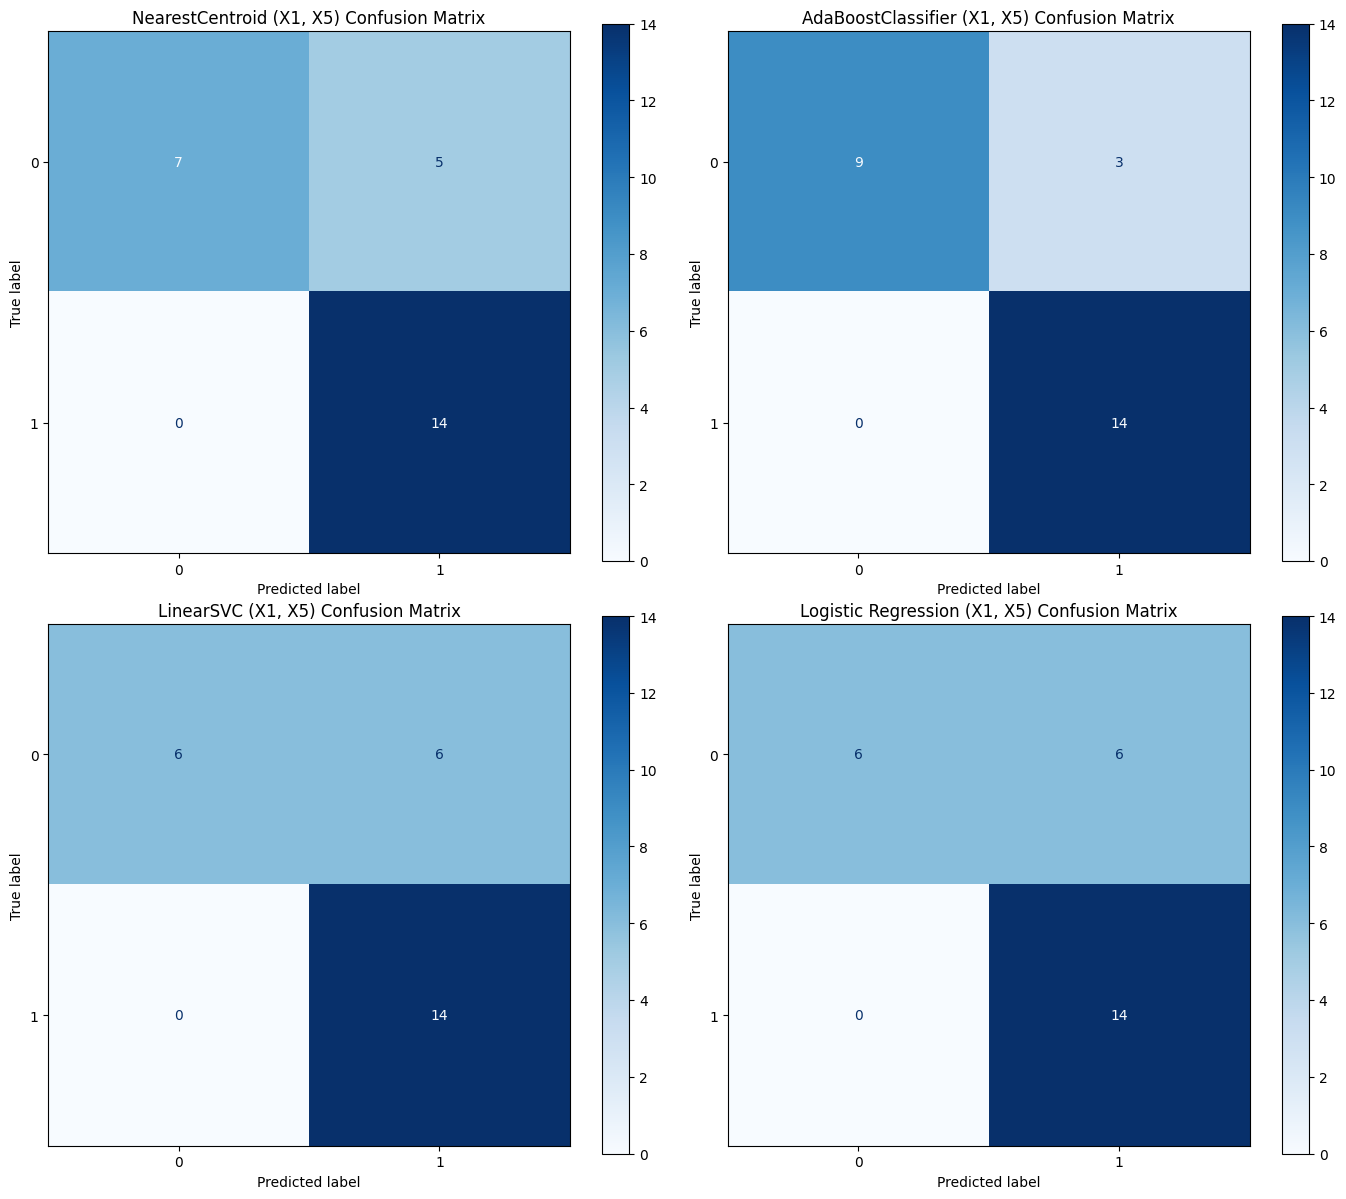

In [ ]:
from sklearn.metrics import classification_report

# Filter X_train and X_test to include only X1 and X5
X_train_selected = X_train[['X1', 'X5']]
X_test_selected = X_test[['X1', 'X5']]

# Initialize and train the classifiers with selected features

# NearestCentroid
nearest_centroid_clf_selected = NearestCentroid()
nearest_centroid_clf_selected.fit(X_train_selected, y_train)
y_pred_nc_selected = nearest_centroid_clf_selected.predict(X_test_selected)

# AdaBoostClassifier
adaboost_clf_selected = AdaBoostClassifier(random_state=seed)
adaboost_clf_selected.fit(X_train_selected, y_train)
y_pred_ada_selected = adaboost_clf_selected.predict(X_test_selected)

# LinearSVC
linearsvc_clf_selected = LinearSVC(random_state=seed, dual=False) #dual=False is set for smaller datasets
linearsvc_clf_selected.fit(X_train_selected, y_train)
y_pred_lsvc_selected = linearsvc_clf_selected.predict(X_test_selected)

# Logistic Regression
logistic_clf_selected = LogisticRegression(random_state=seed)
logistic_clf_selected.fit(X_train_selected, y_train)
y_pred_logistic_selected = logistic_clf_selected.predict(X_test_selected)

classifiers_selected = {
    "NearestCentroid (X1, X5)": (nearest_centroid_clf_selected, y_pred_nc_selected),
    "AdaBoostClassifier (X1, X5)": (adaboost_clf_selected, y_pred_ada_selected),
    "LinearSVC (X1, X5)": (linearsvc_clf_selected, y_pred_lsvc_selected),
    "Logistic Regression (X1, X5)": (logistic_clf_selected, y_pred_logistic_selected)
}

# Print the classification report and confusion matrices
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, (clf, y_pred)) in enumerate(classifiers_selected.items()):
    print(f"\n--- {name} ---")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_estimator(clf, X_test_selected, y_test, cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()